# Pruebas pipeline
Este código pretende entender y conseguir un pipeline definitivo. 

## Funciones necesarias

In [ ]:
#Import libraries
import numpy as np
import pywt
from scipy.signal import argrelextrema
from scipy.interpolate import CubicSpline
from denoising_fun import  denoise_spectrum_uwt
import os
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------
# 0. Leer archivos
# --------------------------------------
#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)

        espectro = df['Sample'].values
        wavelength = df['Wave'].values
        return espectro[16:-16], wavelength[16:-16]
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
    
# --------------------------------------
# 1. Denoising por Wavelet (UWT + sigma clipping)
# --------------------------------------
def denoise_spectrum_uwt(spectrum, wavelet_name='bior3.3', level=None, threshold_sigma=3, method='mad', n_iter_supercam=5):
    """
    Aplica reducción de ruido (denoising) a un espectro usando UWT y sigma clipping.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    wavelet_name : str, opcional
        Nombre del wavelet a utilizar. Por defecto 'bior3.3'.
    level : int, opcional
        Nivel de descomposición wavelet. Si no se especifica, se calcula automáticamente el máximo.
    threshold_sigma : float, opcional
        Umbral de sigma para eliminar coeficientes de detalle (por defecto 3σ).
    method : str, opcional
        Método de sigma clipping: 'mad' o 'supercam'.
    n_iter_supercam : int, opcional
        Número de iteraciones para el método supercam.

    Devuelve:
    ---------
    spectrum_denoised : np.ndarray
        Espectro reconstruido con el ruido eliminado.
    """

    def pad_to_multiple(x, base):
        remainder = len(x) % base
        if remainder == 0:
            return x, 0
        pad_size = base - remainder
        x_padded = np.pad(x, (0, pad_size), mode='edge')
        return x_padded, pad_size

    def sigma_clipping_supercam(coeffs, n_iter=5, threshold_sigma=3):
        filtered_coeffs = []
        for cA, cD in coeffs:
            cD_abs = np.abs(cD)
            mask = np.ones_like(cD_abs, dtype=bool)
            for _ in range(n_iter):
                sigma = np.std(cD_abs[mask])
                mask = cD_abs < (threshold_sigma * sigma)
            sigma_final = np.std(cD_abs[mask])
            threshold = threshold_sigma * sigma_final
            cD_filtered = np.where(cD_abs < threshold, 0, cD)
            filtered_coeffs.append((cA, cD_filtered))
        return filtered_coeffs

    spectrum = np.asarray(spectrum)
    original_len = len(spectrum)

    if level is None:
        # Asegurar que la longitud sea par (agregar padding si es impar)
        if original_len % 2 != 0:
            spectrum = np.pad(spectrum, (0, 1), mode='edge')  # duplica el último valor
            original_len += 1
        level = pywt.swt_max_level(original_len)

    spectrum_padded, pad_size = pad_to_multiple(spectrum, 2 ** level)
    coeffs = pywt.swt(spectrum_padded, wavelet_name, level=level)

    if method == 'mad':
        denoised_coeffs = []
        for cA, cD in coeffs:
            sigma = np.median(np.abs(cD)) / 0.6745
            cD_filtered = np.where(np.abs(cD) < threshold_sigma * sigma, 0, cD)
            denoised_coeffs.append((cA, cD_filtered))
    elif method == 'supercam':
        denoised_coeffs = sigma_clipping_supercam(coeffs, n_iter=n_iter_supercam, threshold_sigma=threshold_sigma)
    else:
        raise ValueError("El parámetro 'method' debe ser 'mad' o 'supercam'.")

    spectrum_denoised = pywt.iswt(denoised_coeffs, wavelet_name)
    return spectrum_denoised[:original_len]

# --------------------------------------
# 2. Eliminación del continuo (por defecto: Robust Baseline Estimation)
# --------------------------------------
def robust_baseline_estimation(spectrum, span=0.1, max_iter=5, b=3.5, tol=1e-3):
    """
    Estima la línea base de un espectro utilizando el algoritmo RBE.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    span : float, opcional
        Proporción del total de puntos a utilizar en la regresión local. Por defecto 0.1 (10%).
    max_iter : int, opcional
        Número máximo de iteraciones para la convergencia. Por defecto 5.
    b : float, opcional
        Constante de ajuste para los pesos bi-square de Tukey. Por defecto 3.5.
    tol : float, opcional
        Tolerancia para la convergencia. Por defecto 1e-3.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    x = np.arange(len(spectrum))
    n = len(spectrum)
    half_window = int(np.ceil(span * n / 2))

    # Estimación inicial de la línea base usando LOWESS
    baseline = np.copy(spectrum)
    for i in range(n):
        start = max(0, i - half_window)
        end = min(n, i + half_window + 1)
        x_local = x[start:end]
        y_local = spectrum[start:end]
        weights = tricube_weight((x_local - x[i]) / half_window)
        p = np.polyfit(x_local, y_local, 1, w=weights)
        baseline[i] = np.polyval(p, x[i])

    # Iteraciones para la estimación robusta
    for iteration in range(max_iter):
        residuals = spectrum - baseline
        sigma = np.median(np.abs(residuals)) / 0.6745
        residuals_standardized = residuals / sigma
        weights_robust = tukey_biweight(residuals_standardized, b)
        baseline_new = np.copy(spectrum)
        for i in range(n):
            start = max(0, i - half_window)
            end = min(n, i + half_window + 1)
            x_local = x[start:end]
            y_local = spectrum[start:end]
            weights = tricube_weight((x_local - x[i]) / half_window) * weights_robust[start:end]
            if np.sum(weights) > 0:
                p = np.polyfit(x_local, y_local, 1, w=weights)
                baseline_new[i] = np.polyval(p, x[i])
            else:
                baseline_new[i] = baseline[i]
        # Comprobar convergencia
        if np.linalg.norm(baseline_new - baseline) < tol:
            break
        baseline = baseline_new

    

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline
    spectrum_corrected[spectrum_corrected < 0] = 0
    return baseline, spectrum_corrected

def tricube_weight(x):
    """Función de peso tricúbico."""
    abs_x = np.abs(x)
    return np.where(abs_x < 1, (1 - abs_x**3)**3, 0)

def tukey_biweight(residuals, b=3.5):
    """Pesos bi-square de Tukey asimétricos."""
    weights = np.ones_like(residuals)
    mask = residuals >= 0
    weights[mask] = (1 - (residuals[mask] / b)**2)**2
    weights[residuals >= b] = 0
    return weights

# --------------------------------------
# 3. Stiching de espectros
# --------------------------------------
def stitch_spectra(spectra, wavelengths):
    """
    Realiza el 'stitching' de múltiples espectros ajustando sus intensidades en zonas de solapamiento.

    Parámetros:
    -----------
    spectra : list of np.ndarray
        Lista de espectros a unir.
    wavelengths : list of np.ndarray
        Lista de longitudes de onda correspondientes a cada espectro.

    Devuelve:
    ---------
    stitched_spectra : list of np.ndarray
        Lista de espectros corregidos con los coeficientes de stitching aplicados.
    """
    #Declaración de los intervalos de solapamiento
    i1 = (wavelengths[1][1], wavelengths[0][len(wavelengths[0])-1])
    i2 = (wavelengths[2][1], wavelengths[1][len(wavelengths[1])-1])
    i3 = (wavelengths[3][1], wavelengths[2][len(wavelengths[2])-1])
    #Aislamiento de los intervalos de solapamiento
    datos_UV1_fil1 = spectra[0][(wavelengths[0] >= i1[0]) & (wavelengths[0] <= i1[1])]
    datos_UV2_fil1 = spectra[1][(wavelengths[1] >= i1[0]) & (wavelengths[1] <= i1[1])]
    datos_UV2_fil2 = spectra[1][(wavelengths[1] >= i2[0]) & (wavelengths[1] <= i2[1])]
    datos_VIS_fil2 = spectra[2][(wavelengths[2] >= i2[0]) & (wavelengths[2] <= i2[1])]
    datos_VIS_fil3 = spectra[2][(wavelengths[2] >= i3[0]) & (wavelengths[2] <= i3[1])]
    datos_NIR_fil3 = spectra[3][(wavelengths[3] >= i3[0]) & (wavelengths[3] <= i3[1])]
    #Extracción de las medianas
    mediana_UV1_fil1 = np.median(datos_UV1_fil1)
    mediana_UV2_fil1 = np.median(datos_UV2_fil1)
    mediana_UV2_fil2 = np.median(datos_UV2_fil2)
    mediana_VIS_fil2 = np.median(datos_VIS_fil2)
    mediana_VIS_fil3 = np.median(datos_VIS_fil3)
    mediana_NIR_fil3 = np.median(datos_NIR_fil3)
    #Cálculo de los coeficientes
    coef1 = mediana_UV2_fil1/mediana_UV1_fil1
    coef2 = mediana_VIS_fil2/mediana_UV2_fil2
    coef3 = mediana_NIR_fil3/mediana_VIS_fil3
    #Aplicación de los coeficientes
    datos_UV1_corr = spectra[0]*coef3*coef2*coef1
    datos_UV2_corr = spectra[1]*coef3*coef2
    datos_VIS_corr = spectra[2]*coef3
    datos_NIR_corr = spectra[3]
    sitich_coefs = [datos_UV1_corr, datos_UV2_corr, datos_VIS_corr, datos_NIR_corr]

    return sitich_coefs


# --------------------------------------
# 3. Plot spectra
# --------------------------------------
def plot_spectra(spectra, wavelengths,nombres = ['UV1', 'UV2', 'VIS', 'NIR'], title="Espectros originales"):
    """
    Plotea múltiples espectros en la misma figura.

    Parámetros:
    ------------
    spectra : list of np.ndarray
        Lista de espectros a plotear.
    wavelengths : list of np.ndarray
        Lista de longitudes de onda correspondientes a cada espectro.
    title : str, opcional
        Título del gráfico. Por defecto "Espectros originales".

    Devuelve:
    ---------
    None
    """
    plt.figure(figsize=(10, 4))
    for i, (spectrum, wavelength) in enumerate(zip(spectra, wavelengths)):
        plt.plot(wavelength, spectrum, label=f'{nombres[i]}')
    plt.title(title)
    plt.xlabel('Longitud de onda (nm)')
    plt.ylabel('Intensidad')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # --------------------------------------
# 5. Recorte de regiones de solapamiento
# --------------------------------------
def trim_overlap_regions(spectra, wavelengths):
    """
    Recorta los espectros para conservar solo las regiones óptimas por detector:
    - UV1 para el solapamiento UV1-UV2
    - VIS para el solapamiento UV2-VIS
    - NIR para el solapamiento VIS-NIR
    - Elimina valores por encima de 1000 nm

    Parámetros:
    -----------
    spectra : list of np.ndarray
        Lista de espectros UV1, UV2, VIS, NIR.
    wavelengths : list of np.ndarray
        Lista de longitudes de onda correspondientes.

    Devuelve:
    ---------
    spectra_trimmed : list of np.ndarray
        Espectros recortados.
    wavelengths_trimmed : list of np.ndarray
        Longitudes de onda recortadas.
    """

    # Obtener intervalos de solapamiento
    i1_min, i1_max = wavelengths[1][1], wavelengths[0][-1]
    i2_min, i2_max = wavelengths[2][1], wavelengths[1][-1]
    i3_min, i3_max = wavelengths[3][1], wavelengths[2][-1]

    espectro_uv1 = spectra[0]
    wl_uv1 = wavelengths[0]
    # UV2: quedarse solo con su parte no solapada
    mask_uv2 = (wavelengths[1] >= i1_max) & (wavelengths[1] <= i2_min) 
    espectro_uv2 = spectra[1][mask_uv2]
    wl_uv2 = wavelengths[1][mask_uv2]

    # VIS: quitar el solapamiento con NIR
    mask_vis = (wavelengths[2] <= i3_min)
    espectro_vis = spectra[2][mask_vis]
    wl_vis = wavelengths[2][mask_vis]

    # NIR: desde i3_min hasta 1000nm
    mask_nir = wavelengths[3] <= 1000
    espectro_nir = spectra[3][mask_nir]
    wl_nir = wavelengths[3][mask_nir]

    return [espectro_uv1, espectro_uv2, espectro_vis, espectro_nir], [wl_uv1, wl_uv2, wl_vis, wl_nir]



## Leer archivos

In [3]:
ruta_espectros = os.path.join('..', 'Spectra', '20250321_First_test')

UV1 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)

# Nombres y organización
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
spectra = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]

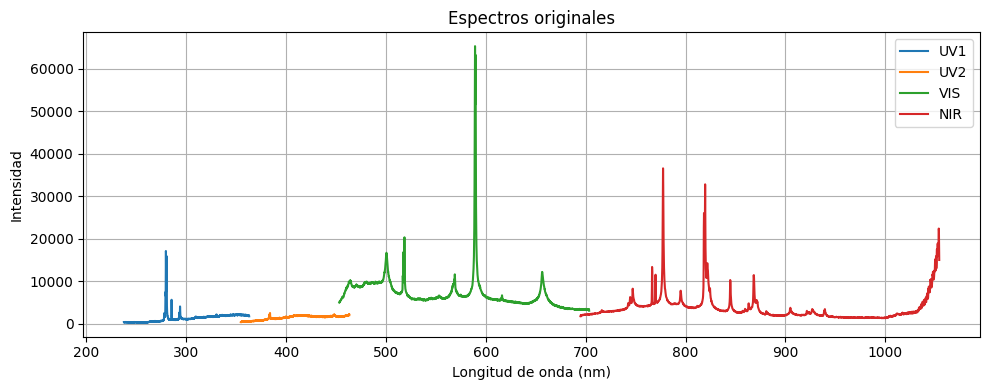

In [4]:
#plot original
plot_spectra(spectra, wavelengths)

## Pipeline 1. Stiching->Denoising->Baseline removal

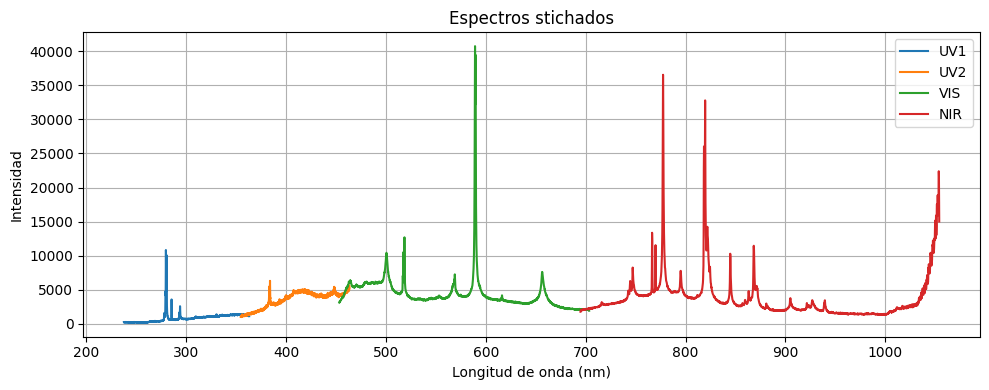

In [5]:
#Stiching
spectra_stiched = stitch_spectra(spectra, wavelengths)
plot_spectra(spectra_stiched, wavelengths, title="Espectros stichados")

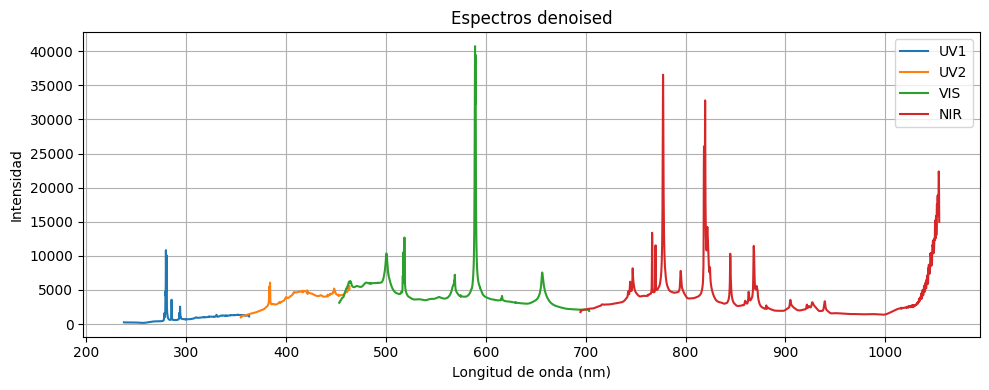

In [6]:
#Denoising
spectra_denoised = [denoise_spectrum_uwt(spectrum) for spectrum in spectra_stiched]
plot_spectra(spectra_denoised, wavelengths, nombres, title="Espectros denoised")

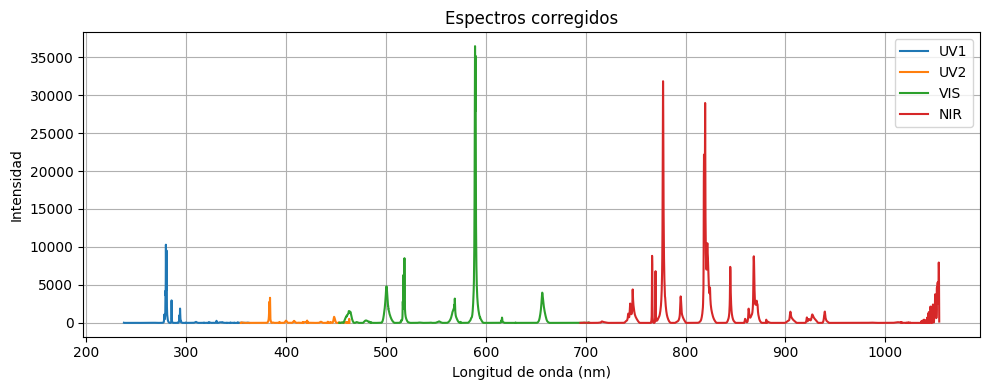

In [7]:
#bckground removal
spectra_corrected = [robust_baseline_estimation(spectrum)[1] for spectrum in spectra_denoised]
plot_spectra(spectra_corrected, wavelengths, nombres, title="Espectros corregidos")

## Pipeline 2. Denoising->Stiching->Baseline removal

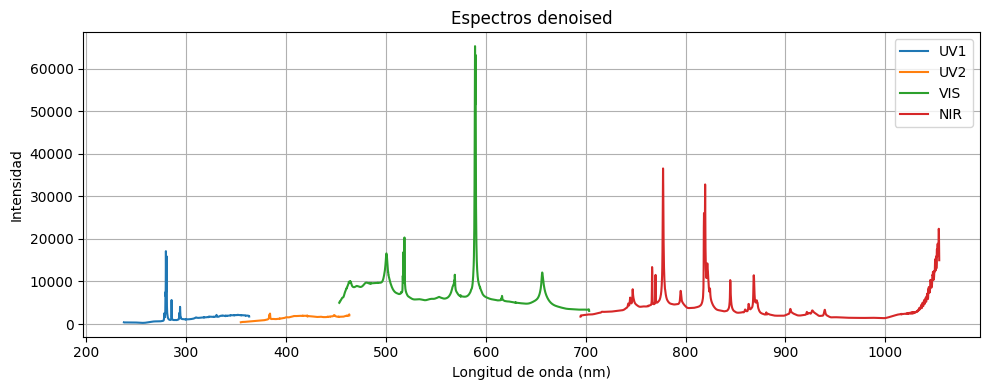

In [8]:
#Denoising
spectra_denoised_2 = [denoise_spectrum_uwt(spectrum) for spectrum in spectra]
plot_spectra(spectra_denoised_2, wavelengths, title="Espectros denoised")

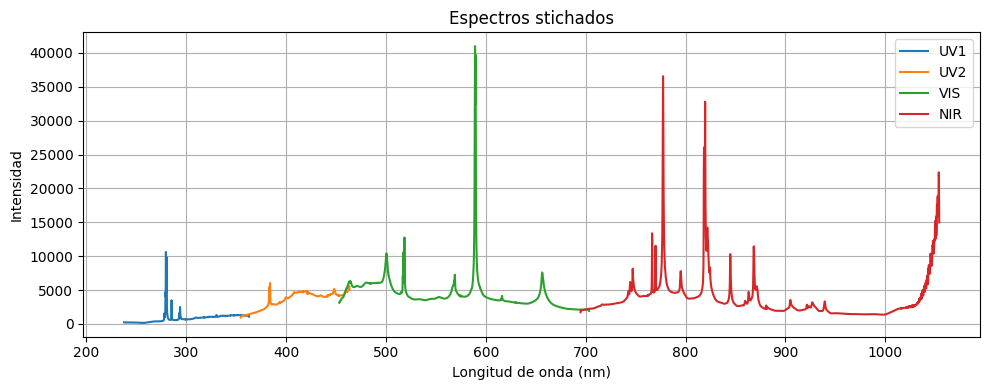

In [9]:
#Stiching
spectra_stiched_2 = stitch_spectra(spectra_denoised_2, wavelengths)
plot_spectra(spectra_stiched_2, wavelengths, title="Espectros stichados")

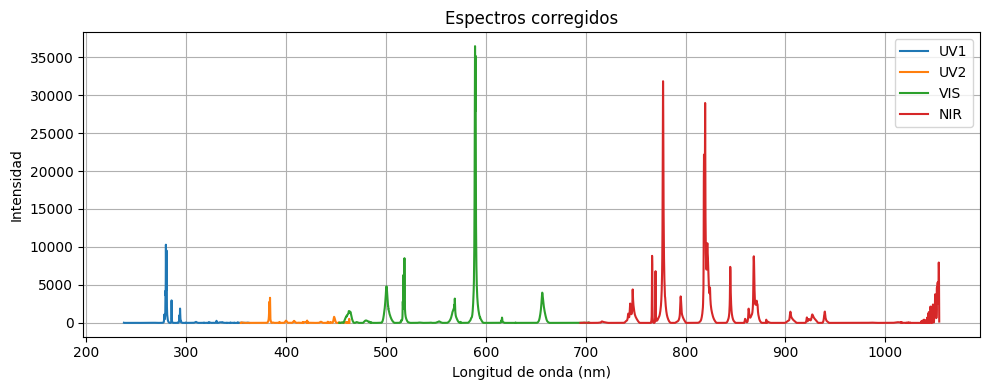

In [10]:
#bckground removal
spectra_corrected_2 = [robust_baseline_estimation(spectrum)[1] for spectrum in spectra_stiched_2]
plot_spectra(spectra_corrected, wavelengths, nombres, title="Espectros corregidos")

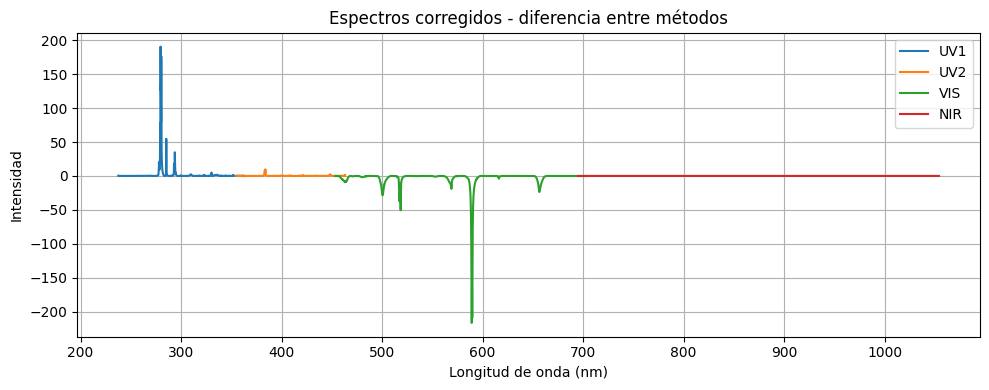

In [11]:
#restamos ambos método para observar si hay diferencias mayores
spectra_diff = [spectrum - spectrum_2 for spectrum, spectrum_2 in zip(spectra_corrected, spectra_corrected_2)]
plot_spectra(spectra_diff, wavelengths, nombres, title="Espectros corregidos - diferencia entre métodos")

## Pipeline 3. Denoising->Stiching->Trim->Baseline removal ->Normalization

In [92]:
import sys
sys.path.append('C:/Nacho/Universidad/Prácticas Raman/LIBS_QUANTIFICATION_INTA')
from LIBS_quantification_toolbox import * 

In [ ]:
spectra1, wavelength, names =cargar_espectros('20250321_First_test','Sulfato50_position3_Burst5-n1',quitar_extremos=True )
spectra2, _, _ =cargar_espectros('20250321_First_test','Sulfato50_position3_Burst5-n2',quitar_extremos=True )
spectra3, _, _ =cargar_espectros('20250321_First_test','Sulfato50_position3_Burst5-n3',quitar_extremos=True )
spectra4, _, _ =cargar_espectros('20250321_First_test','Sulfato50_position3_Burst5-n4',quitar_extremos=True )
spectra5, _, _ =cargar_espectros('20250321_First_test','Sulfato50_position2_Burst5-n5',quitar_extremos=True )

In [118]:
'''
plot_spectra(wavelength, spectra1, names, titulo="Espectros corregidos - LV1-n1")
plot_spectra(wavelength, spectra2, names, titulo="Espectros corregidos - LV1-n2")
plot_spectra(wavelength, spectra3, names, titulo="Espectros corregidos - LV1-n3")
plot_spectra(wavelength, spectra4, names, titulo="Espectros corregidos - LV1-n4")
plot_spectra(wavelength, spectra5, names, titulo="Espectros corregidos - LV1-n5")'''

'\nplot_spectra(wavelength, spectra1, names, titulo="Espectros corregidos - LV1-n1")\nplot_spectra(wavelength, spectra2, names, titulo="Espectros corregidos - LV1-n2")\nplot_spectra(wavelength, spectra3, names, titulo="Espectros corregidos - LV1-n3")\nplot_spectra(wavelength, spectra4, names, titulo="Espectros corregidos - LV1-n4")\nplot_spectra(wavelength, spectra5, names, titulo="Espectros corregidos - LV1-n5")'

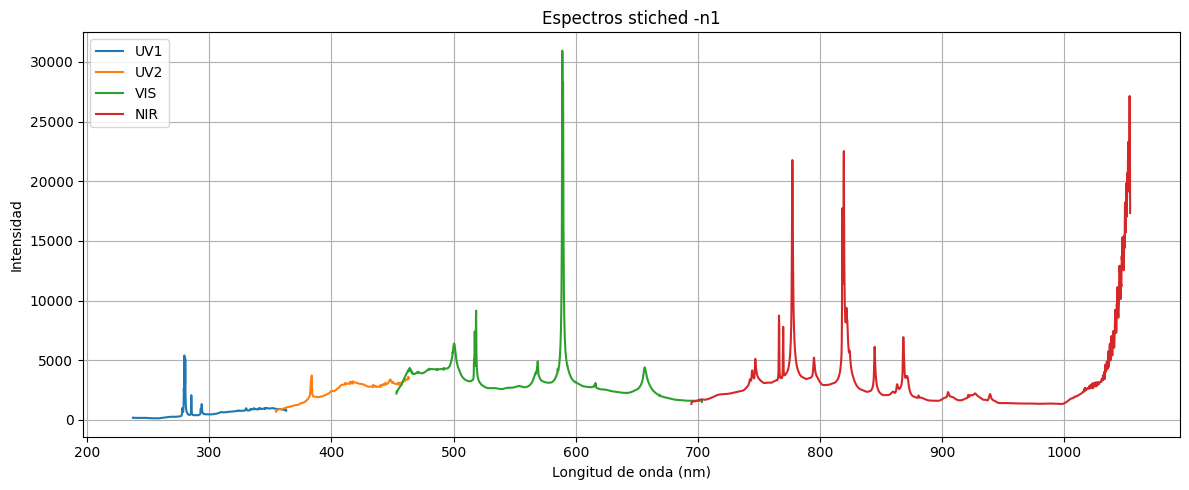

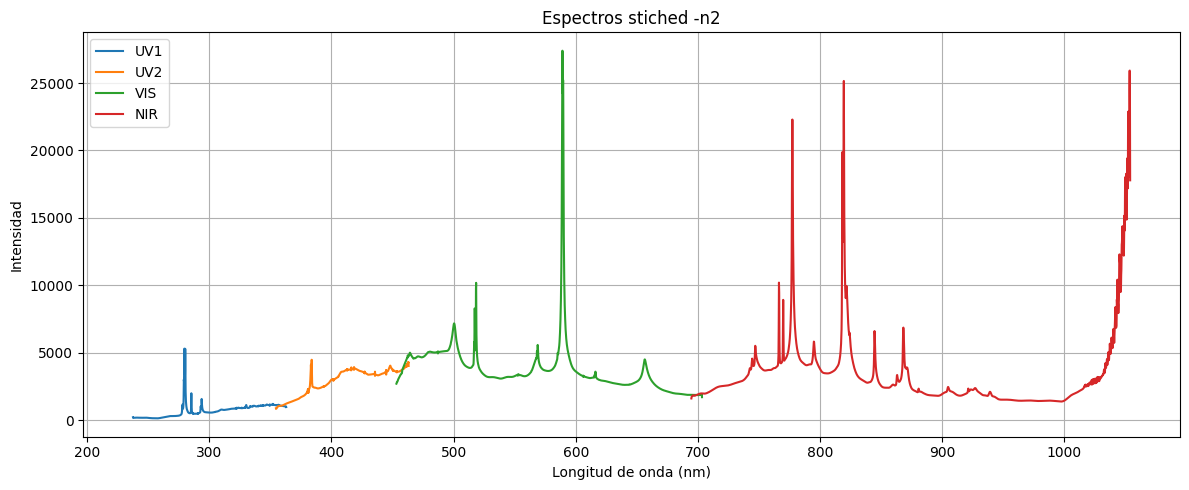

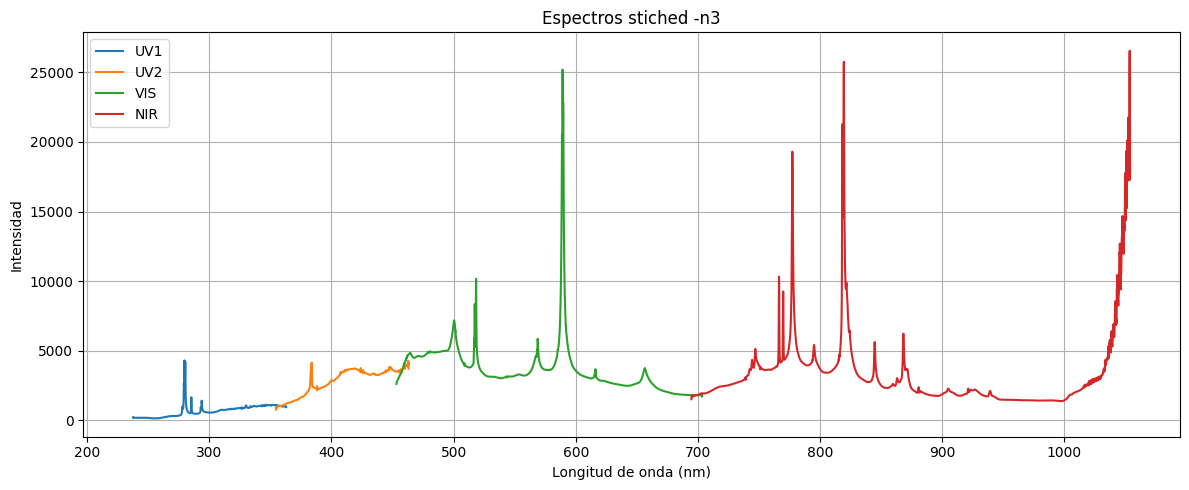

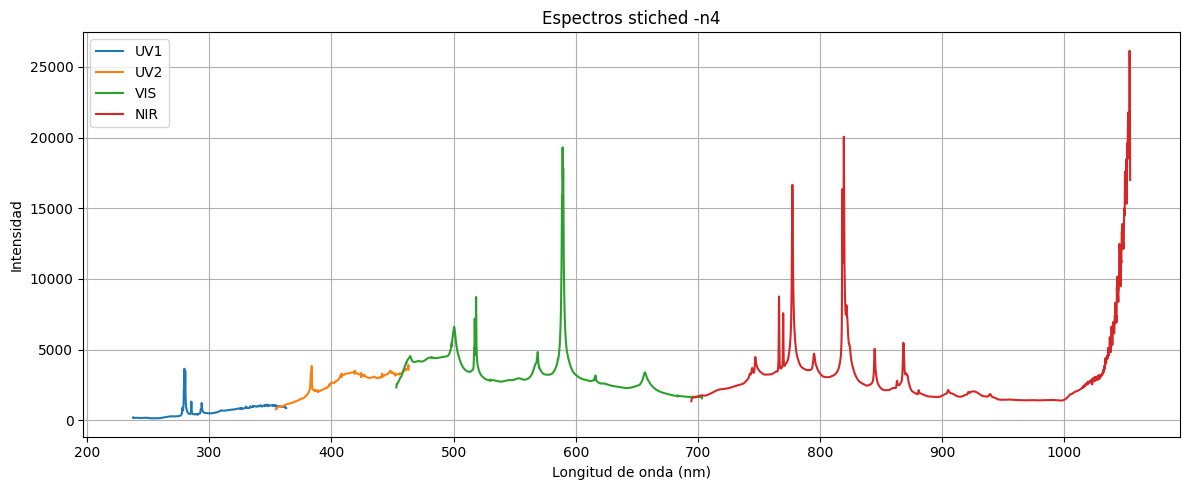

'\nspectra_lv1_1,wavelength_lv1 = apply_preprocessing(spectra1, wavelength)\nspectra_lv1_2,_ = apply_preprocessing(spectra2, wavelength)\nspectra_lv1_3,_ = apply_preprocessing(spectra3, wavelength)\nspectra_lv1_4,_ = apply_preprocessing(spectra4, wavelength)\nspectra_lv1_5,_ = apply_preprocessing(spectra5, wavelength)'

In [ ]:
#Spectrum 1
spectra_denoised1 = []
for i, spectrum in enumerate(spectra1):
        spectrum_denoised1 = denoise_spectrum_uwt(spectrum)
        spectra_denoised1.append(spectrum_denoised1)
spectra1 = stitch_spectra(spectra_denoised1, wavelength)
plot_spectra(wavelength, spectra1, names, titulo="Espectros stiched -n1")
spectra1, wavelength_lv1 =trim_overlap_regions(spectra1, wavelength)
spectra_lv1_1 = []
continuum_1= []
for i, spectrum in enumerate(spectra1):
        continuum, spectrum_baseless = robust_baseline_estimation(spectrum)
        spectra_lv1_1.append(spectrum_baseless)
        continuum_1.append(continuum)

#Spectrum 2
spectra_denoised2 = []
for i, spectrum in enumerate(spectra2):
        spectrum_denoised2 = denoise_spectrum_uwt(spectrum)
        spectra_denoised2.append(spectrum_denoised2)
spectra2 = stitch_spectra(spectra_denoised2, wavelength)
plot_spectra(wavelength, spectra2, names, titulo="Espectros stiched -n2")
spectra2, _ =trim_overlap_regions(spectra2, wavelength)
spectra_lv1_2 = []
continuum_2= []
for i, spectrum in enumerate(spectra2):
        continuum, spectrum_baseless = robust_baseline_estimation(spectrum)
        spectra_lv1_2.append(spectrum_baseless)
        continuum_2.append(continuum)

#Spectrum 3
spectra_denoised3 = []
for i, spectrum in enumerate(spectra3):
        spectrum_denoised3 = denoise_spectrum_uwt(spectrum)
        spectra_denoised3.append(spectrum_denoised3)
spectra3 = stitch_spectra(spectra_denoised3, wavelength)
plot_spectra(wavelength, spectra3, names, titulo="Espectros stiched -n3")
spectra3, _ =trim_overlap_regions(spectra3, wavelength)
spectra_lv1_3 = []
continuum_3= []
for i, spectrum in enumerate(spectra3):
        continuum, spectrum_baseless = robust_baseline_estimation(spectrum)
        spectra_lv1_3.append(spectrum_baseless)
        continuum_3.append(continuum)

#Spectrum 4
spectra_denoised4 = []
for i, spectrum in enumerate(spectra4):
        spectrum_denoised4 = denoise_spectrum_uwt(spectrum)
        spectra_denoised4.append(spectrum_denoised4)
spectra4 = stitch_spectra(spectra_denoised4, wavelength)
plot_spectra(wavelength, spectra4, names, titulo="Espectros stiched -n4")
spectra4, _ =trim_overlap_regions(spectra4, wavelength)
spectra_lv1_4 = []
continuum_4= []
for i, spectrum in enumerate(spectra4):
        continuum, spectrum_baseless = robust_baseline_estimation(spectrum)
        spectra_lv1_4.append(spectrum_baseless)
        continuum_4.append(continuum)

#Spectrum 5
spectra_denoised5 = []
for i, spectrum in enumerate(spectra5):
        spectrum_denoised5 = denoise_spectrum_uwt(spectrum)
        spectra_denoised5.append(spectrum_denoised5)
spectra5 = stitch_spectra(spectra_denoised5, wavelength)
plot_spectra(wavelength, spectra5, names, titulo="Espectros stiched -n5")
spectra5, _ =trim_overlap_regions(spectra5, wavelength)
spectra_lv1_5 = []
for i, spectrum in enumerate(spectra5):
        continuum, spectrum_baseless = robust_baseline_estimation(spectrum)
        spectra_lv1_5.append(spectrum_baseless)
        continuum_5.append(continuum)


'''
spectra_lv1_1,wavelength_lv1 = apply_preprocessing(spectra1, wavelength)
spectra_lv1_2,_ = apply_preprocessing(spectra2, wavelength)
spectra_lv1_3,_ = apply_preprocessing(spectra3, wavelength)
spectra_lv1_4,_ = apply_preprocessing(spectra4, wavelength)
spectra_lv1_5,_ = apply_preprocessing(spectra5, wavelength)'''

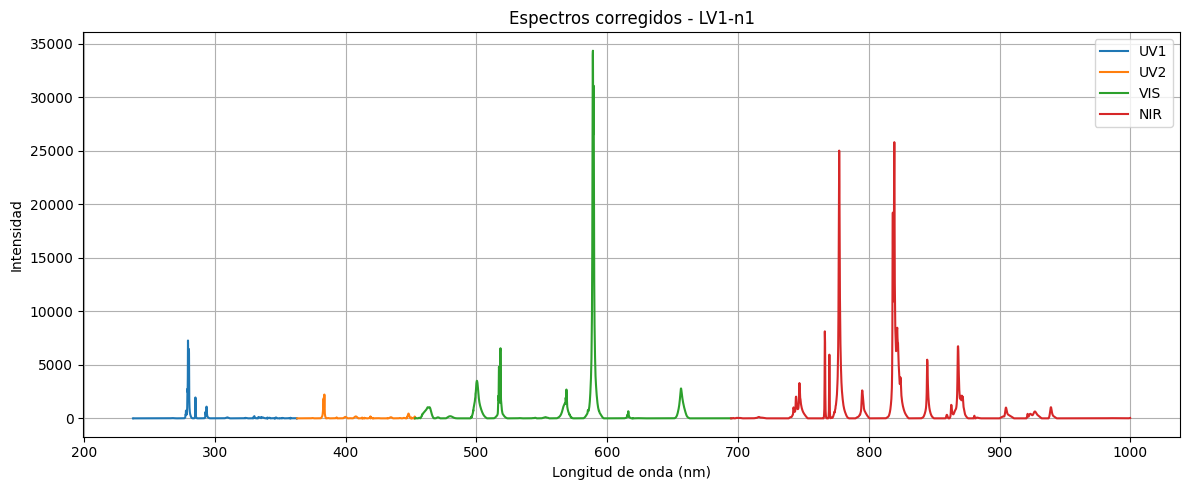

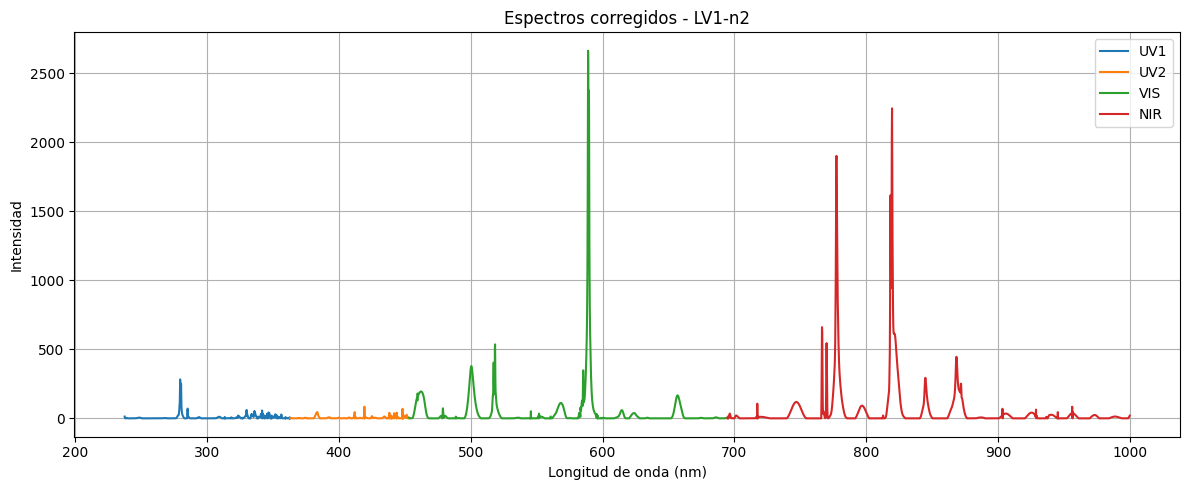

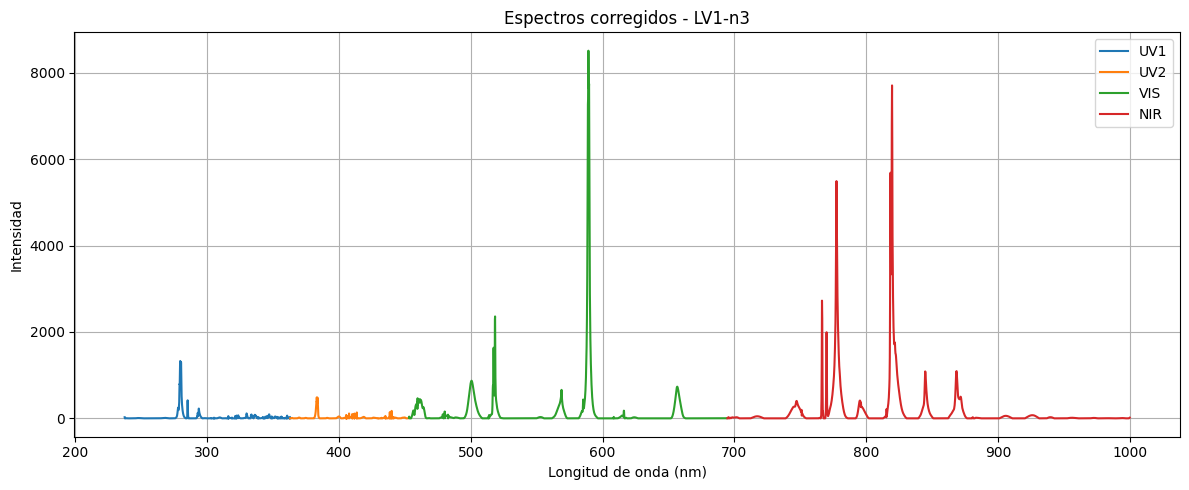

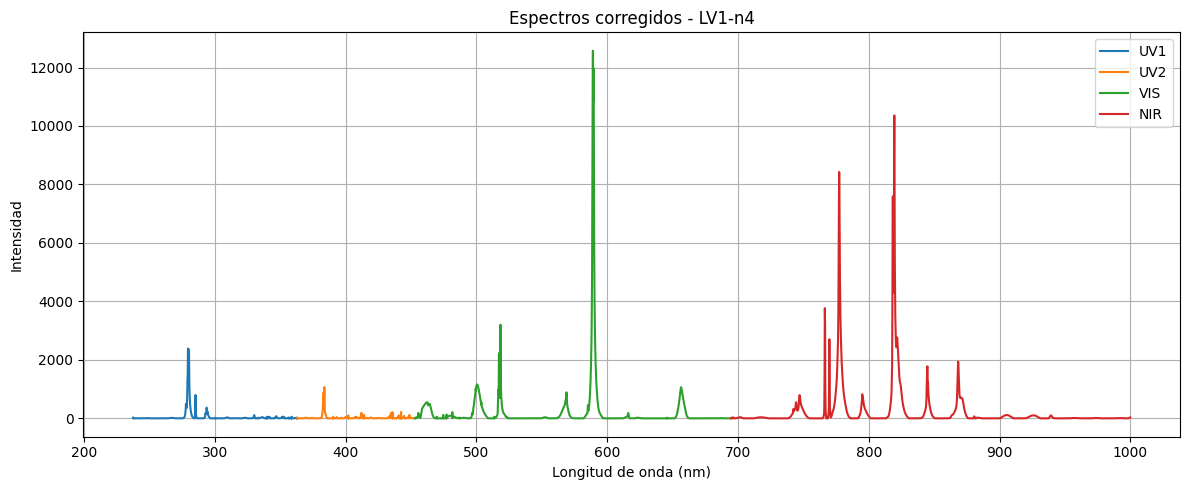

In [ ]:
plot_spectra(wavelength_lv1, spectra_lv1_1, names, titulo="Espectros corregidos - LV1-n1")
plot_spectra(wavelength_lv1, spectra_lv1_2, names, titulo="Espectros corregidos - LV1-n2")
plot_spectra(wavelength_lv1, spectra_lv1_3, names, titulo="Espectros corregidos - LV1-n3")
plot_spectra(wavelength_lv1, spectra_lv1_4, names, titulo="Espectros corregidos - LV1-n4")
plot_spectra(wavelength_lv1, spectra_lv1_5, names, titulo="Espectros corregidos - LV1-n5")

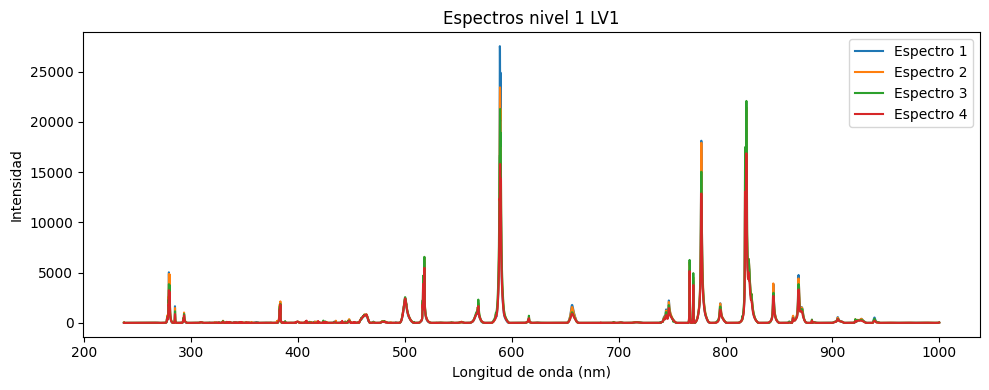

In [ ]:
full_wavelength = np.concatenate(wavelength_lv1)

full_spectra_lv1_1 = np.concatenate(spectra_lv1_1)
full_continuum_1 = np.concatenate(continuum_1)
full_spectra_lv1_2 = np.concatenate(spectra_lv1_2)
full_continuum_2 = np.concatenate(continuum_2)
full_spectra_lv1_3 = np.concatenate(spectra_lv1_3)
full_continuum_3 = np.concatenate(continuum_3)
full_spectra_lv1_4 = np.concatenate(spectra_lv1_4)
full_continuum_4 = np.concatenate(continuum_4)
full_spectra_lv1_5 = np.concatenate(spectra_lv1_5)
full_continuum_5 = np.concatenate(continuum_5)

#hacemos un gráfico mostrando juntos todos los espectros
plt.figure(figsize=(10,4))

plt.plot(full_wavelength, full_spectra_lv1_1, label='Espectro 1')
plt.plot(full_wavelength, full_spectra_lv1_2, label='Espectro 2')
plt.plot(full_wavelength, full_spectra_lv1_3, label='Espectro 3')
plt.plot(full_wavelength, full_spectra_lv1_4, label='Espectro 4')
plt.plot(full_wavelength, full_spectra_lv1_5, label='Espectro 5')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Intensidad')
plt.title('Espectros nivel 1 LV1')
plt.legend()
plt.tight_layout()
plt.show()


### Probamos la normalización por suma total una vez quitado el continuo

In [136]:
def normalizar_por_suma(espectro):
    """
    Normaliza un espectro dividiendo cada valor entre la suma total del espectro.

    Parámetros:
    ------------
    espectro : array_like
        Espectro original (array 1D de intensidades).

    Devuelve:
    ---------
    espectro_normalizado : np.ndarray
        Espectro normalizado.
    """
    espectro = np.asarray(espectro)
    suma_total = np.sum(espectro)

    if suma_total == 0:
        raise ValueError("La suma del espectro es cero, no se puede normalizar.")

    espectro_normalizado = espectro / suma_total
    return espectro_normalizado

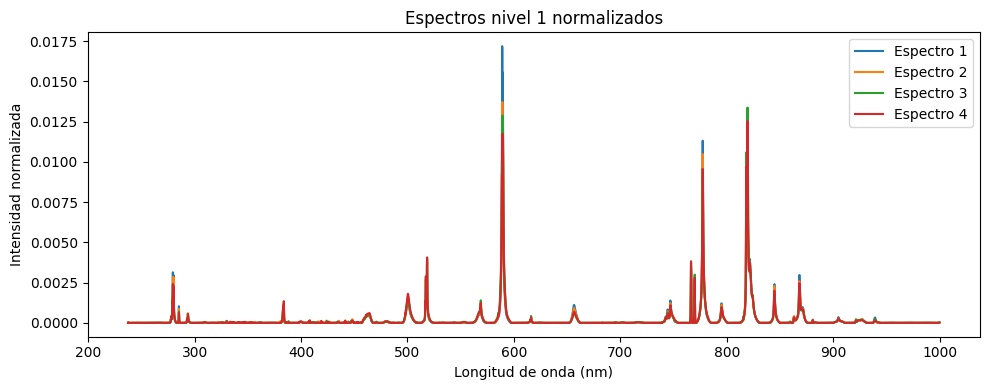

In [ ]:
norm_spectra_lv1_1 = normalizar_por_suma(full_spectra_lv1_1)
norm_spectra_lv1_2 = normalizar_por_suma(full_spectra_lv1_2)
norm_spectra_lv1_3 = normalizar_por_suma(full_spectra_lv1_3)
norm_spectra_lv1_4 = normalizar_por_suma(full_spectra_lv1_4)
norm_spectra_lv1_5 = normalizar_por_suma(full_spectra_lv1_5)

#hacemos un gráfico mostrando juntos todos los espectros
plt.figure(figsize=(10,4))

plt.plot(full_wavelength, norm_spectra_lv1_1, label='Espectro 1')
plt.plot(full_wavelength, norm_spectra_lv1_2, label='Espectro 2')
plt.plot(full_wavelength, norm_spectra_lv1_3, label='Espectro 3')
plt.plot(full_wavelength, norm_spectra_lv1_4, label='Espectro 4')
plt.plot(full_wavelength, norm_spectra_lv1_5, label='Espectro 5')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Intensidad normalizada')
plt.title('Espectros nivel 1 normalizados')
plt.legend()
plt.tight_layout()
plt.show()



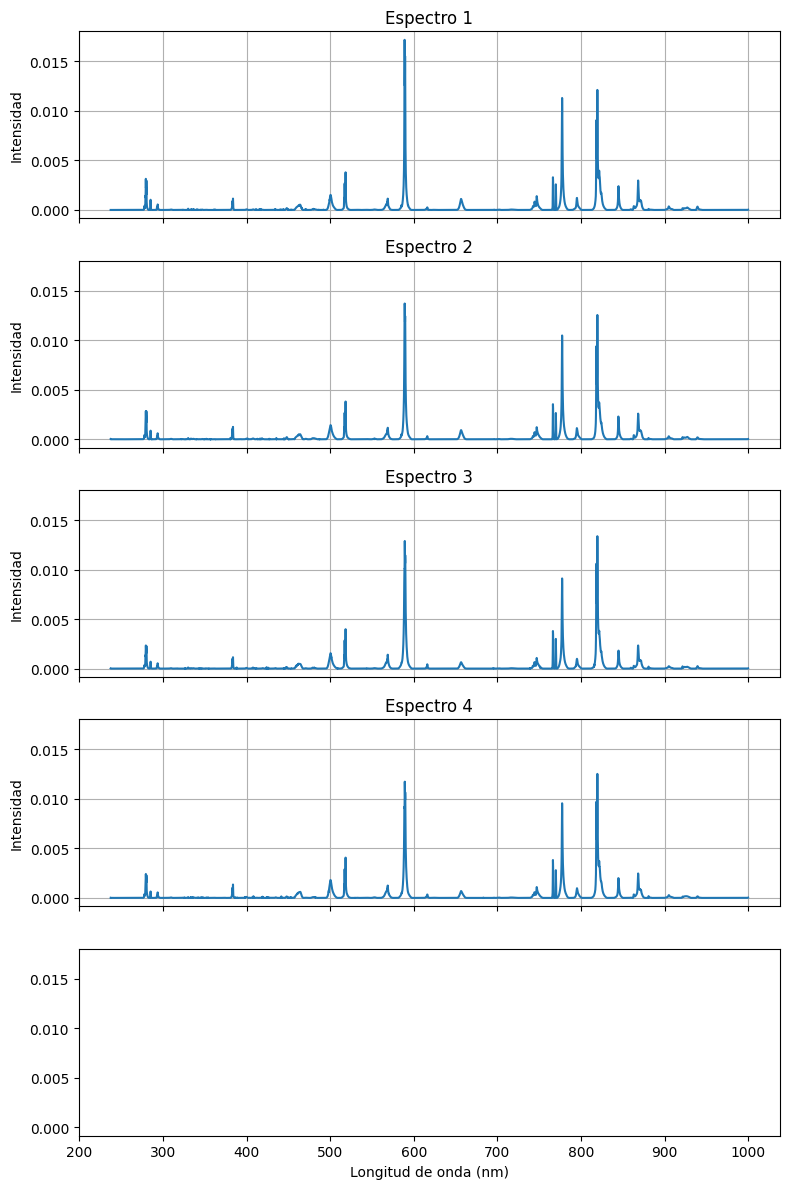

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, sharey=True, figsize=(8, 12))

spectra = [
    norm_spectra_lv1_1,
    norm_spectra_lv1_2,
    norm_spectra_lv1_3,
    norm_spectra_lv1_4,
    norm_spectra_lv1_5,
]
titles = [f'Espectro {i}' for i in range(1, 6)]

for ax, spec, title in zip(axes, spectra, titles):
    ax.plot(full_wavelength, spec)
    ax.set_ylabel('Intensidad')
    ax.set_title(title)
    ax.grid(True)

axes[-1].set_xlabel('Longitud de onda (nm)')

plt.tight_layout()
plt.show()

### Probamos la normalización por contínuo (con el contínuo ya quitado)

In [122]:
def normalizar_por_continuo(continuum, espectro):
    """
    Normaliza un espectro dividiendo cada valor entre la suma total del espectro.

    Parámetros:
    ------------
    espectro : array_like
        Espectro original (array 1D de intensidades).

    Devuelve:
    ---------
    espectro_normalizado : np.ndarray
        Espectro normalizado.
    """
    espectro = np.asarray(espectro)
    suma_total = np.sum(continuum)

    if suma_total == 0:
        raise ValueError("La suma del contínuo es cero, no se puede normalizar.")

    espectro_normalizado = espectro / suma_total
    return espectro_normalizado

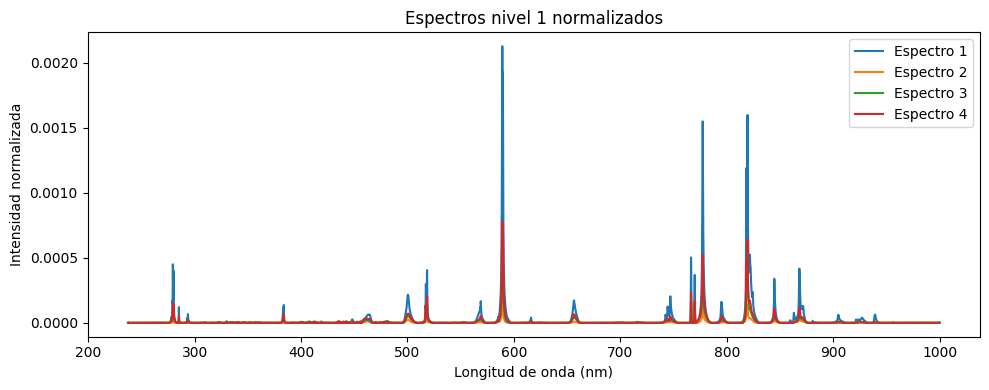

In [ ]:
norm_spectra_lv1_1 = normalizar_por_continuo(full_continuum_1, full_spectra_lv1_1)
norm_spectra_lv1_2 = normalizar_por_continuo(full_continuum_2, full_spectra_lv1_2)
norm_spectra_lv1_3 = normalizar_por_continuo(full_continuum_3, full_spectra_lv1_3)
norm_spectra_lv1_4 = normalizar_por_continuo(full_continuum_4, full_spectra_lv1_4)
norm_spectra_lv1_5 = normalizar_por_continuo(full_continuum_5, full_spectra_lv1_5)

#hacemos un gráfico mostrando juntos todos los espectros
plt.figure(figsize=(10,4))

plt.plot(full_wavelength, norm_spectra_lv1_1, label='Espectro 1')
plt.plot(full_wavelength, norm_spectra_lv1_2, label='Espectro 2')
plt.plot(full_wavelength, norm_spectra_lv1_3, label='Espectro 3')
plt.plot(full_wavelength, norm_spectra_lv1_4, label='Espectro 4')
#plt.plot(full_wavelength, norm_spectra_lv1_5, label='Espectro 5')

plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Intensidad normalizada')
plt.title('Espectros nivel 1 normalizados')
plt.legend()
plt.tight_layout()
plt.show()

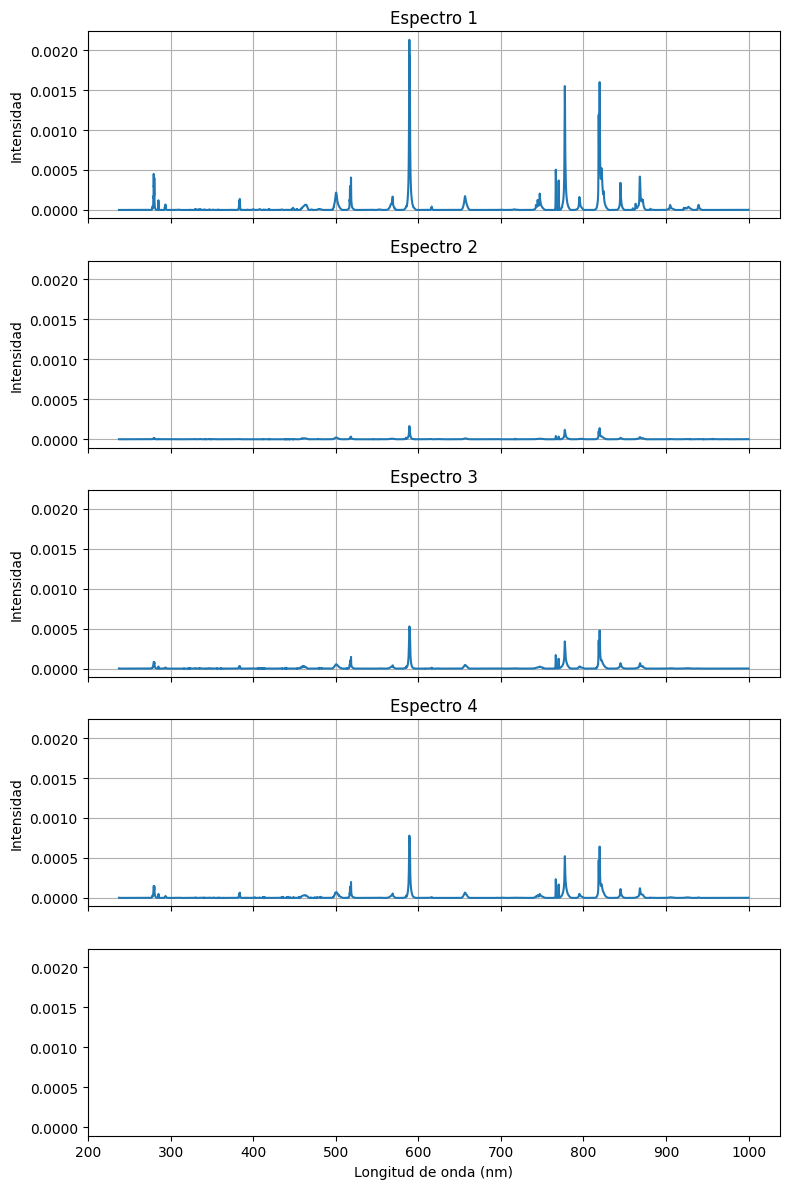

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, sharey=True, figsize=(8, 12))

spectra = [
    norm_spectra_lv1_1,
    norm_spectra_lv1_2,
    norm_spectra_lv1_3,
    norm_spectra_lv1_4,
    norm_spectra_lv1_5,
]
titles = [f'Espectro {i}' for i in range(1, 6)]

for ax, spec, title in zip(axes, spectra, titles):
    ax.plot(full_wavelength, spec)
    ax.set_ylabel('Intensidad')
    ax.set_title(title)
    ax.grid(True)

axes[-1].set_xlabel('Longitud de onda (nm)')

plt.tight_layout()
plt.show()

### Figura de error

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def replication_score(spectra):
    """
    spectra: lista de arrays 1D (todas deben tener misma longitud)
    
    Devuelve un dict con:
      - mean_RMSE: RMSE medio vs. espectro promedio
      - mean_R2:   R² medio vs. espectro promedio
      - mean_r:    correlación Pearson media entre pares
    """
    # apilar en matriz (N espectros × M canales)
    M = np.vstack(spectra)
    
    # 1) RMSE y R² vs. espectro medio
    mean_spec = M.mean(axis=0)
    r2s   = [r2_score(mean_spec, spec)            for spec in M]
    
    
    return {
        'mean_R2':   np.mean(r2s),
        'std_R2':    np.std(r2s),
    }

# --- Ejemplo de uso ---
scores = replication_score([
    norm_spectra_lv1_1,
    norm_spectra_lv1_2,
    norm_spectra_lv1_3,
    norm_spectra_lv1_4,
    norm_spectra_lv1_5
])
print(scores)


{'mean_R2': 0.9883583886681584, 'std_R2': 0.008311214344920933}


### Código completo para guardar datos automáticamente

In [153]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

import sys
sys.path.append('C:/Nacho/Universidad/Prácticas Raman/LIBS_QUANTIFICATION_INTA')
from LIBS_quantification_toolbox import *

def replication_r2(spectra):
    M = np.vstack(spectra)
    mean_spec = M.mean(axis=0)
    r2s = [r2_score(mean_spec, s) for s in M]
    return float(np.mean(r2s)), float(np.std(r2s))

def normalize_sum(spec):
    s = spec.sum()
    return spec / s if s!=0 else spec

def normalize_continuum(spec, cont):
    c = cont.sum()
    return spec/c if c!=0 else spec

# — Parámetros de usuario —
out_root = r'C:/Nacho/Universidad/Prácticas Raman/Imagenes pipeline spectra/Pipeline 3'
run_name  = "Yeso"
suffixes  = [
    'Yeso_posicion1_Burst5-n1',
    'Yeso_posicion1_Burst5-n2',
    'Yeso_posicion1_Burst5-n3',
    'Yeso_posicion1_Burst5-n4',
    'Yeso_posicion1_Burst5-n5',
]
data_root = '20250328_OHO-SN3_LIBS-Quantif_samples/5.Yeso'
# — no tocar abajo —

# crea carpetas
out_dir  = os.path.join(out_root, run_name)
sum_dir  = os.path.join(out_dir, "Suma total")
cont_dir = os.path.join(out_dir, "Continuo")
os.makedirs(sum_dir, exist_ok=True)
os.makedirs(cont_dir, exist_ok=True)

all_spectra   = []
all_continuums= None
wavelength_lv1= None

# procesa cada sufijo
for suf in suffixes:
    specs, wl, names = cargar_espectros(data_root, suf, quitar_extremos=True)
    den = [denoise_spectrum_uwt(s) for s in specs]
    st  = stitch_spectra(den, wl)
    st, wl_lv1 = trim_overlap_regions(st, wl)

    baseless, conts = [], []
    for s in st:
        cont, base = robust_baseline_estimation(s)
        baseless.append(base)
        conts.append(cont)

    all_spectra.append(np.concatenate(baseless))
    if all_continuums is None:
        all_continuums = []
    all_continuums.append(np.concatenate(conts))
    wavelength_lv1 = wl_lv1

full_wl = np.concatenate(wavelength_lv1)

# — guardo los LV1 antes de normalizar —
fig, axes = plt.subplots(len(all_spectra),1, sharex=True, figsize=(8,2*len(all_spectra)))
for ax, spec, i in zip(axes, all_spectra, range(1,len(all_spectra)+1)):
    ax.plot(full_wl, spec)
    ax.set_ylabel(f'Esp{i}')
axes[-1].set_xlabel('λ (nm)')
plt.suptitle('Espectros LV1 (stitched + baseline) previos a normalización')
pre_fn = os.path.join(out_dir, "pre_norm.png")
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(pre_fn)
plt.close()

# función para normalizar, graficar y score
def process_and_save(norm_specs, folder, title_suffix):
    # todos juntos
    plt.figure(figsize=(10,4))
    for i,s in enumerate(norm_specs,1):
        plt.plot(full_wl, s, label=f"Esp{i}")
    plt.xlabel('λ (nm)'); plt.ylabel('Intensidad')
    plt.title(f'Normalización {title_suffix} - todos'); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(folder, f"todos_{title_suffix}.png"))
    plt.close()

    # subplots individuales
    fig, axes = plt.subplots(len(norm_specs),1, sharex=True, figsize=(8,2*len(norm_specs)))
    for ax,s,i in zip(axes, norm_specs, range(1,len(norm_specs)+1)):
        ax.plot(full_wl, s); ax.set_ylabel(f'Esp{i}')
    axes[-1].set_xlabel('λ (nm)')
    plt.suptitle(f'Normalización {title_suffix}')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(folder, f"subplots_{title_suffix}.png"))
    plt.close()

    # R²
    mean_r2, std_r2 = replication_r2(norm_specs)
    with open(os.path.join(folder,"score.txt"), "w") as f:
        f.write(f"mean_R2: {mean_r2:.4f}\nstd_R2: {std_r2:.4f}\n")

# normalización suma total
norm_sum = [ normalize_sum(s) for s in all_spectra ]
process_and_save(norm_sum, sum_dir, "suma_total")

# normalización contínuo
norm_cont = [ normalize_continuum(s, c) for s,c in zip(all_spectra, all_continuums) ]
process_and_save(norm_cont, cont_dir, "continuo")

print("Listo! resultados en:", out_dir)


Listo! resultados en: C:/Nacho/Universidad/Prácticas Raman/Imagenes pipeline spectra/Pipeline 3\Yeso
